# EV Charging Allocation with Multi-Port Time-Sharing
## 1 — Setup

In [1]:
from __future__ import annotations

import math
import heapq
import random
import itertools
from collections import defaultdict, deque
from dataclasses import dataclass, field
from enum import Enum
from typing import Optional, Callable, Any

import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 0
RNG = random.Random(SEED)
NPRNG = np.random.default_rng(SEED)

## 2 — Domain types

In [2]:
class ChargerType(Enum):
    L2s = "L2s"
    L2f = "L2f"
    DCm = "DCm"
    DCh = "DCh"

CHARGER_SPECS: dict[ChargerType, tuple[float, float]] = {
    ChargerType.L2s: (7.0, 0.12),
    ChargerType.L2f: (11.0, 0.15),
    ChargerType.DCm: (50.0, 0.30),
    ChargerType.DCh: (150.0, 0.45),
}

In [3]:
@dataclass
class EV:
    id: int
    arrival_time: float
    energy_required_kWh: float
    deadline: float
    max_cost: float
    max_distance: float
    weight: float
    compatible_types: list[ChargerType]
    home_station: int
    location: tuple[float, float] = (0.0, 0.0)

@dataclass
class EVStats:
    ev_id: int
    arrival_time: float = 0.0
    wait_time: float = 0.0
    charge_time: float = 0.0
    total_time: float = 0.0
    cost: float = 0.0
    energy_delivered: float = 0.0
    energy_required: float = 0.0
    assigned_station: Optional[int] = None
    assigned_type: Optional[str] = None
    on_chain: bool = False
    deadline_met: bool = False
    served: bool = False
    rejected: bool = False

In [4]:
class EventKind(Enum):
    E1_ARRIVAL = "arrival"
    E2_STATION_ARRIVAL = "station_arrival"
    E3_CHARGE_START = "charge_start"
    E4_CHARGE_END = "charge_end"
    E5_CHAIN_ADMIT = "chain_admit"
    E6_CHAIN_COMPLETE = "chain_complete"
    E7_CHAIN_SWITCH = "chain_switch"
    E8_PRICE_CHANGE = "price_change"
    E9_DEADLINE_MISS = "deadline_miss"
    E10_REJECT = "reject"

@dataclass
class EventLog:
    time: float
    kind: EventKind
    ev_id: Optional[int] = None
    station_id: Optional[int] = None
    details: dict = field(default_factory=dict)

class Tracer:
    def __init__(self) -> None:
        self.events: list[EventLog] = []

    def log(self, time: float, kind: EventKind,
            ev_id: Optional[int] = None,
            station_id: Optional[int] = None,
            **details) -> None:
        self.events.append(EventLog(time, kind, ev_id, station_id, details))

    def to_dataframe(self) -> pd.DataFrame:
        if not self.events:
            return pd.DataFrame(columns=["time", "kind", "ev_id", "station_id", "details"])
        return pd.DataFrame([{
            "time": e.time,
            "kind": e.kind.value,
            "ev_id": e.ev_id,
            "station_id": e.station_id,
            "details": e.details,
        } for e in self.events])

## 3 — TOU pricing

In [5]:
class TOUSchedule:

    def __init__(self, intervals: list[tuple[float, float, float]]) -> None:
        ints = sorted(intervals, key=lambda x: x[0])
        assert abs(ints[0][0]) < 1e-9, "TOU must start at 0"
        assert abs(ints[-1][1] - 24.0) < 1e-9, "TOU must end at 24"
        for (_, e1, _), (s2, _, _) in zip(ints, ints[1:]):
            assert abs(e1 - s2) < 1e-9, "TOU intervals must be contiguous"
        self.intervals = ints

    def price_at(self, t: float, base_price: float) -> float:
        h = t % 24.0
        for s, e, m in self.intervals:
            if s <= h < e:
                return m * base_price
        return self.intervals[-1][2] * base_price

    def integrate_cost(self, t_start: float, t_end: float,
                       power_kW: float, base_price: float) -> float:
        if t_end <= t_start:
            return 0.0
        total = 0.0
        cur = t_start
        max_iter = int((t_end - t_start) / 0.001) + len(self.intervals) * 10 + 100
        it = 0
        while cur < t_end - 1e-15 and it < max_iter:
            it += 1
            h = cur % 24.0
            cycle_base = cur - h
            for s, e, m in self.intervals:
                if s <= h < e:
                    seg_end_abs = cycle_base + e
                    next_t = min(seg_end_abs, t_end)
                    dt = next_t - cur
                    total += m * base_price * power_kW * dt
                    cur = next_t
                    break
            else:
                break
        return total

def default_tou() -> TOUSchedule:
    return TOUSchedule([
        (0.0, 7.0, 1.0),
        (7.0, 17.0, 1.3),
        (17.0, 20.0, 1.8),
        (20.0, 22.0, 1.3),
        (22.0, 24.0, 1.0),
    ])

## 4 — Stochastic processes

In [6]:
@dataclass
class AttributeSampler:
    energy_mean: float = 35.0
    energy_std: float = 12.0
    energy_min: float = 10.0
    energy_max: float = 60.0
    slack_min: float = 0.5
    slack_max: float = 4.0
    max_cost_min: float = 5.0
    max_cost_max: float = 50.0
    max_distance_min: float = 1.0
    max_distance_max: float = 20.0
    rho_min_power_options: tuple = (0.0, 7.0, 50.0)
    rho_min_power_weights: tuple = (0.6, 0.3, 0.1)

    def sample(self, rng: random.Random) -> dict:
        for _ in range(50):
            e = rng.gauss(self.energy_mean, self.energy_std)
            if self.energy_min <= e <= self.energy_max:
                break
        else:
            e = max(self.energy_min, min(self.energy_max, self.energy_mean))
        slack = rng.uniform(self.slack_min, self.slack_max)
        max_cost = rng.uniform(self.max_cost_min, self.max_cost_max)
        max_distance = rng.uniform(self.max_distance_min, self.max_distance_max)
        weight = rng.random()
        rho = rng.choices(self.rho_min_power_options,
                          weights=self.rho_min_power_weights, k=1)[0]
        compatible = [t for t, (p, _) in CHARGER_SPECS.items() if p >= rho]
        return {
            "energy_required_kWh": e,
            "slack": slack,
            "max_cost": max_cost,
            "max_distance": max_distance,
            "weight": weight,
            "compatible_types": compatible,
        }

def default_sampler() -> AttributeSampler:
    return AttributeSampler()

In [7]:
def poisson_arrivals(env: simpy.Environment,
                     rate: float,
                     sampler: AttributeSampler,
                     on_arrival: Callable[[EV], None],
                     rng: random.Random,
                     stations: list,
                     max_evs: Optional[int] = None):
    counter = itertools.count()
    while True:
        inter = rng.expovariate(rate)
        yield env.timeout(inter)
        eid = next(counter)
        if max_evs is not None and eid >= max_evs:
            return
        attrs = sampler.sample(rng)
        home_idx = rng.randrange(len(stations))
        sx, sy = stations[home_idx].location
        loc = (sx + rng.uniform(-2.0, 2.0), sy + rng.uniform(-2.0, 2.0))
        ev = EV(
            id=eid,
            arrival_time=env.now,
            energy_required_kWh=attrs["energy_required_kWh"],
            deadline=env.now + attrs["slack"],
            max_cost=attrs["max_cost"],
            max_distance=attrs["max_distance"],
            weight=attrs["weight"],
            compatible_types=attrs["compatible_types"],
            home_station=home_idx,
            location=loc,
        )
        on_arrival(ev)

## 5 — Charger pool and multi-port primitives

In [8]:
class ChargerPool:

    def __init__(self, env: simpy.Environment, charger_type: ChargerType, capacity: int) -> None:
        self.env = env
        self.type = charger_type
        self.capacity = capacity
        self.power_kW, self.base_price = CHARGER_SPECS[charger_type]
        self.resource = simpy.Resource(env, capacity=capacity)
        self._last_change = 0.0
        self._busy_integral = 0.0
        self._last_busy = 0

    def _tick(self) -> None:
        now = self.env.now
        dt = now - self._last_change
        self._busy_integral += self._last_busy * dt
        self._last_change = now
        self._last_busy = len(self.resource.users)

    @property
    def n_busy(self) -> int: return len(self.resource.users)
    @property
    def n_free(self) -> int: return self.capacity - self.n_busy
    @property
    def n_queued(self) -> int: return len(self.resource.queue)

    def utilization(self) -> float:
        self._tick()
        if self.env.now <= 0: return 0.0
        return self._busy_integral / (self.env.now * self.capacity)

In [9]:
class ChainScheduler:
    def next(self, chain: "DaisyChain", env_now: float) -> tuple[Optional[EV], Optional[float]]:
        raise NotImplementedError

class DaisyChain:

    def __init__(self, env: simpy.Environment, chain_id: int,
                 n_slots: int, charger_type: ChargerType,
                 scheduler: ChainScheduler,
                 price_factor: float = 0.7) -> None:
        self.env = env
        self.id = chain_id
        self.n_slots = n_slots
        self.type = charger_type
        self.power_kW, self.base_price = CHARGER_SPECS[charger_type]
        self.price_factor = price_factor
        self.scheduler = scheduler
        self.admitted: list[EV] = []
        self.progress_kWh: dict[int, float] = {}
        self.energize_events: dict[int, simpy.Event] = {}
        self.active_ev: Optional[EV] = None
        self.scheduler_wakeup: simpy.Event = env.event()
        self.slot_freed: simpy.Event = env.event()
        self.energized_since: dict[int, float] = {}
        self._first_energized_at: dict[int, float] = {}
        self._last_change = 0.0
        self._busy_integral = 0.0
        self._last_busy = 0

    def _tick(self) -> None:
        now = self.env.now
        dt = now - self._last_change
        self._busy_integral += self._last_busy * dt
        self._last_change = now
        self._last_busy = 1 if self.active_ev is not None else 0

    def wake_scheduler(self) -> None:
        self._tick()
        if not self.scheduler_wakeup.triggered:
            self.scheduler_wakeup.succeed()

    def signal_slot_freed(self) -> None:
        if not self.slot_freed.triggered:
            self.slot_freed.succeed()

    def try_admit(self, ev: EV) -> bool:
        if len(self.admitted) >= self.n_slots:
            return False
        self.admitted.append(ev)
        self.progress_kWh[ev.id] = 0.0
        self.energize_events[ev.id] = self.env.event()
        self.wake_scheduler()
        return True

    def release(self, ev: EV) -> None:
        if ev in self.admitted:
            self.admitted.remove(ev)
        self.progress_kWh.pop(ev.id, None)
        self.energize_events.pop(ev.id, None)
        self.energized_since.pop(ev.id, None)
        if self.active_ev is ev:
            self.active_ev = None
        self.signal_slot_freed()
        self.slot_freed = self.env.event()
        self.wake_scheduler()

    def utilization(self) -> float:
        self._tick()
        if self.env.now <= 0: return 0.0
        return self._busy_integral / self.env.now

## 6 — Station aggregator

In [10]:
@dataclass
class Station:
    id: int
    location: tuple[float, float]
    pools: dict[ChargerType, ChargerPool]
    chains: list[DaisyChain] = field(default_factory=list)

    def compatible_pools(self, ev: EV) -> list[tuple[ChargerType, ChargerPool]]:
        return [(t, p) for t, p in self.pools.items() if t in ev.compatible_types]

    def compatible_chains(self, ev: EV) -> list[DaisyChain]:
        return [c for c in self.chains if c.type in ev.compatible_types]

    def min_wait_estimate(self, charger_type: ChargerType,
                          avg_service_hours: float = 1.0) -> float:
        if charger_type not in self.pools:
            return math.inf
        pool = self.pools[charger_type]
        n_ahead = pool.n_busy + pool.n_queued
        if pool.n_free > 0:
            return 0.0
        return ((n_ahead - pool.capacity + 1) / pool.capacity) * avg_service_hours

In [11]:
def distance(ev_loc: tuple[float, float], station: Station) -> float:
    dx = ev_loc[0] - station.location[0]
    dy = ev_loc[1] - station.location[1]
    return math.hypot(dx, dy)

def travel_time(ev_loc: tuple[float, float], station: Station,
                v_avg_kmh: float = 30.0) -> float:
    return distance(ev_loc, station) / v_avg_kmh

## 7 — Heuristic upper-level policies

In [12]:
class UpperPolicy:
    name: str = "abstract"

    def assign(self, ev: EV, stations: list[Station], env: simpy.Environment,
               tou: TOUSchedule, tracer: Optional[Tracer] = None
               ) -> Optional[tuple[Station, ChargerType, Optional[DaisyChain]]]:
        raise NotImplementedError

def _candidates(ev: EV, stations: list[Station], v_avg: float = 30.0
                ) -> list[tuple[Station, ChargerType, Optional[DaisyChain], float]]:
    out = []
    for s in stations:
        tt = travel_time(ev.location, s, v_avg)
        if distance(ev.location, s) > ev.max_distance:
            continue
        for t, _pool in s.compatible_pools(ev):
            out.append((s, t, None, tt))
        for ch in s.compatible_chains(ev):
            out.append((s, ch.type, ch, tt))
    return out

def _expected_charging_cost(ev: EV, charger_type: ChargerType, env_now: float,
                            tou: TOUSchedule,
                            chain: Optional["DaisyChain"] = None) -> float:
    power, base = CHARGER_SPECS[charger_type]
    if chain is not None:
        base = base * chain.price_factor
    duration = ev.energy_required_kWh / power
    return tou.integrate_cost(env_now, env_now + duration, power, base)

def _expected_wait(s: Station, t: ChargerType, chain: Optional[DaisyChain],
                   avg_service: float = 1.0) -> float:
    if chain is not None:
        return (len(chain.admitted) / max(chain.n_slots, 1)) * avg_service
    return s.min_wait_estimate(t, avg_service)

In [13]:
class GreedyCost(UpperPolicy):
    name = "GreedyCost"

    def assign(self, ev, stations, env, tou, tracer=None):
        cands = _candidates(ev, stations, v_avg=30.0)
        if not cands:
            return None
        best, best_score = None, math.inf
        for s, t, ch, _tt in cands:
            cost = _expected_charging_cost(ev, t, env.now, tou, chain=ch)
            if cost > ev.max_cost:
                continue
            if cost < best_score:
                best_score, best = cost, (s, t, ch)
        return best

class GreedyDelay(UpperPolicy):
    name = "GreedyDelay"

    def assign(self, ev, stations, env, tou, tracer=None):
        cands = _candidates(ev, stations)
        if not cands:
            return None
        best, best_score = None, math.inf
        for s, t, ch, tt in cands:
            cost = _expected_charging_cost(ev, t, env.now, tou, chain=ch)
            if cost > ev.max_cost:
                continue
            score = tt + _expected_wait(s, t, ch)
            if score < best_score:
                best_score, best = score, (s, t, ch)
        return best

class WeightedGreedy(UpperPolicy):
    name = "WeightedGreedy"

    def assign(self, ev, stations, env, tou, tracer=None):
        cands = _candidates(ev, stations)
        if not cands:
            return None
        best, best_score = None, math.inf
        for s, t, ch, _tt in cands:
            cost = _expected_charging_cost(ev, t, env.now, tou, chain=ch)
            if cost > ev.max_cost:
                continue
            d = distance(ev.location, s)
            score = ev.weight * (cost / max(ev.max_cost, 1e-9)) + \
                    (1.0 - ev.weight) * (d / max(ev.max_distance, 1e-9))
            if score < best_score:
                best_score, best = score, (s, t, ch)
        return best

In [14]:
class LeastLoaded(UpperPolicy):
    name = "LeastLoaded"

    def assign(self, ev, stations, env, tou, tracer=None):
        cands = _candidates(ev, stations)
        if not cands:
            return None
        best, best_score = None, math.inf
        for s, t, ch, _tt in cands:
            cost = _expected_charging_cost(ev, t, env.now, tou, chain=ch)
            if cost > ev.max_cost:
                continue
            if ch is not None:
                load = len(ch.admitted) / max(ch.n_slots, 1)
            else:
                pool = s.pools[t]
                load = (pool.n_busy + pool.n_queued) / max(pool.capacity, 1)
            if load < best_score:
                best_score, best = load, (s, t, ch)
        return best

## 8 — Chain-level scheduler (EDF)

In [15]:
class EDFChain(ChainScheduler):
    name = "EDFChain"
    def next(self, chain, env_now):
        if not chain.admitted:
            return None, None
        return min(chain.admitted, key=lambda e: e.deadline), None

## 9 — Simulator

In [16]:
class Simulator:

    def __init__(self,
                 env: simpy.Environment,
                 stations: list[Station],
                 upper_policy: UpperPolicy,
                 tou: TOUSchedule,
                 sampler: AttributeSampler,
                 rng: random.Random,
                 v_avg: float = 30.0) -> None:
        self.env = env
        self.stations = stations
        self.upper_policy = upper_policy
        self.tou = tou
        self.sampler = sampler
        self.rng = rng
        self.v_avg = v_avg
        self.tracer = Tracer()
        self.stats: list[EVStats] = []
        self._chain_done_events: dict[int, simpy.Event] = {}
        self._chain_outcome: dict[int, dict] = {}
        for s in stations:
            for ch in s.chains:
                env.process(self._chain_scheduler_loop(ch))

    def run(self, arrival_rate: float, duration: float,
            max_evs: Optional[int] = None) -> pd.DataFrame:
        self.env.process(
            poisson_arrivals(self.env, arrival_rate, self.sampler,
                             self._on_arrival, self.rng, self.stations, max_evs)
        )
        self.env.run(until=duration)
        return self.stats_df()

    def stats_df(self) -> pd.DataFrame:
        if not self.stats:
            return pd.DataFrame(columns=[
                "ev_id", "arrival_time", "wait_time", "charge_time", "total_time",
                "cost", "energy_delivered", "energy_required",
                "assigned_station", "assigned_type", "on_chain",
                "deadline_met", "served", "rejected",
            ])
        return pd.DataFrame([s.__dict__ for s in self.stats])

    def _on_arrival(self, ev: EV) -> None:
        self.env.process(self._ev_lifecycle(ev))

In [17]:
def _wrap_inject(target_cls, method_name: str):
    def deco(fn):
        setattr(target_cls, method_name, fn)
        return fn
    return deco

In [18]:
@_wrap_inject(Simulator, "_ev_lifecycle")
def _ev_lifecycle(self, ev: EV):
        env = self.env
        self.tracer.log(env.now, EventKind.E1_ARRIVAL, ev_id=ev.id,
                        station_id=ev.home_station)
        stats = EVStats(ev_id=ev.id, arrival_time=ev.arrival_time,
                        energy_required=ev.energy_required_kWh)

        choice = self.upper_policy.assign(ev, self.stations, env, self.tou, self.tracer)
        if choice is None:
            self.tracer.log(env.now, EventKind.E10_REJECT, ev_id=ev.id)
            stats.rejected = True
            stats.total_time = 0.0
            self.stats.append(stats)
            return
        station, charger_type, chain = choice
        stats.assigned_station = station.id
        stats.assigned_type = charger_type.value
        stats.on_chain = (chain is not None)

        tt = travel_time(ev.location, station, self.v_avg)
        yield env.timeout(tt)
        self.tracer.log(env.now, EventKind.E2_STATION_ARRIVAL, ev_id=ev.id,
                        station_id=station.id)

        if chain is not None:
            yield from self._charge_on_chain(ev, station, chain, stats)
        else:
            yield from self._charge_on_pool(ev, station, charger_type, stats)

        stats.total_time = env.now - ev.arrival_time
        self.stats.append(stats)

In [19]:
@_wrap_inject(Simulator, "_charge_on_pool")
def _charge_on_pool(self, ev: EV, station: Station,
                        charger_type: ChargerType, stats: EVStats):
        env = self.env
        pool = station.pools[charger_type]
        wait_start = env.now
        req = pool.resource.request()
        try:
            deadline_timeout = env.timeout(max(0.0, ev.deadline - env.now))
            result = yield req | deadline_timeout
            if req in result:
                stats.wait_time = env.now - wait_start
                self.tracer.log(env.now, EventKind.E3_CHARGE_START, ev_id=ev.id,
                                station_id=station.id, type=charger_type.value)
                power = pool.power_kW
                full_charge_time = ev.energy_required_kWh / power
                slack = max(0.0, ev.deadline - env.now)
                charge_time = min(full_charge_time, slack)
                t_start = env.now
                yield env.timeout(charge_time)
                t_end = env.now
                stats.charge_time = charge_time
                stats.energy_delivered = power * charge_time
                stats.cost = self.tou.integrate_cost(t_start, t_end, power, pool.base_price)
                stats.deadline_met = (stats.energy_delivered >= ev.energy_required_kWh - 1e-6)
                stats.served = True
                self.tracer.log(env.now, EventKind.E4_CHARGE_END, ev_id=ev.id,
                                station_id=station.id, served=True,
                                deadline_met=stats.deadline_met)
            else:
                stats.wait_time = env.now - wait_start
                stats.deadline_met = False
                stats.served = False
                self.tracer.log(env.now, EventKind.E9_DEADLINE_MISS, ev_id=ev.id,
                                station_id=station.id, phase="queue")
        finally:
            if req in pool.resource.users:
                pool.resource.release(req)
            elif req in pool.resource.queue:
                try:
                    pool.resource.queue.remove(req)
                except ValueError:
                    pass

In [20]:
@_wrap_inject(Simulator, "_charge_on_chain")
def _charge_on_chain(self, ev: EV, station: Station,
                         chain: DaisyChain, stats: EVStats):
        env = self.env
        wait_start = env.now

        while not chain.try_admit(ev):
            slot_event = chain.slot_freed
            dl = env.timeout(max(0.0, ev.deadline - env.now))
            res = yield slot_event | dl
            if slot_event not in res:
                stats.wait_time = env.now - wait_start
                stats.deadline_met = False
                stats.served = False
                self.tracer.log(env.now, EventKind.E9_DEADLINE_MISS, ev_id=ev.id,
                                station_id=station.id, phase="admission")
                return
        self.tracer.log(env.now, EventKind.E5_CHAIN_ADMIT, ev_id=ev.id,
                        station_id=station.id, chain_id=chain.id)

        done_event = env.event()
        self._chain_done_events[ev.id] = done_event
        self._chain_outcome[ev.id] = {}

        chain.wake_scheduler()

        try:
            yield done_event
        finally:
            self._chain_done_events.pop(ev.id, None)

        outcome = self._chain_outcome.pop(ev.id, {})
        stats.wait_time = outcome.get("wait_time", env.now - wait_start)
        stats.charge_time = outcome.get("charge_time", 0.0)
        stats.energy_delivered = outcome.get("energy_delivered", 0.0)
        stats.cost = outcome.get("cost", 0.0)
        stats.deadline_met = outcome.get("deadline_met", False)
        stats.served = outcome.get("served", False)
        self.tracer.log(env.now, EventKind.E6_CHAIN_COMPLETE, ev_id=ev.id,
                        station_id=station.id, chain_id=chain.id,
                        served=stats.served, deadline_met=stats.deadline_met)

In [21]:
@_wrap_inject(Simulator, "_chain_scheduler_loop")
def _chain_scheduler_loop(self, chain: DaisyChain):
        env = self.env
        while True:
            if not chain.admitted:
                yield chain.scheduler_wakeup
                chain.scheduler_wakeup = env.event()
                continue

            now = env.now
            expired = [ev for ev in list(chain.admitted) if ev.deadline <= now]
            for ev in expired:
                kWh = chain.progress_kWh.get(ev.id, 0.0)
                first_dict = getattr(chain, "_first_energized_at", {})
                first_e = first_dict.get(ev.id, ev.deadline)
                if ev.id in self._chain_outcome:
                    prev = self._chain_outcome[ev.id]
                    self._chain_outcome[ev.id] = {
                        "wait_time": first_e - ev.arrival_time,
                        "charge_time": kWh / chain.power_kW if chain.power_kW > 0 else 0.0,
                        "energy_delivered": kWh,
                        "cost": prev.get("cost", 0.0),
                        "deadline_met": kWh >= ev.energy_required_kWh - 1e-6,
                        "served": kWh > 1e-6,
                    }
                chain.release(ev)
                ev_done = self._chain_done_events.get(ev.id)
                if ev_done is not None and not ev_done.triggered:
                    ev_done.succeed()
            if expired:
                continue

            active, quantum = chain.scheduler.next(chain, env.now)
            if active is None:
                yield chain.scheduler_wakeup
                chain.scheduler_wakeup = env.event()
                continue

            if chain.active_ev is not active:
                self.tracer.log(env.now, EventKind.E7_CHAIN_SWITCH,
                                ev_id=active.id, station_id=None,
                                chain_id=chain.id,
                                prev_ev=chain.active_ev.id if chain.active_ev else None)
            chain.active_ev = active
            first_dict = getattr(chain, "_first_energized_at", None)
            if first_dict is None:
                first_dict = {}
                chain._first_energized_at = first_dict
            first_dict.setdefault(active.id, env.now)
            chain.energized_since[active.id] = env.now

            remaining_kWh = active.energy_required_kWh - chain.progress_kWh.get(active.id, 0.0)
            time_to_complete = remaining_kWh / chain.power_kW if chain.power_kW > 0 else math.inf
            time_to_any_deadline = min((ev.deadline - env.now) for ev in chain.admitted)
            time_to_any_deadline = max(0.0, time_to_any_deadline)
            slice_dt = min(time_to_complete, time_to_any_deadline)
            if quantum is not None:
                slice_dt = min(slice_dt, quantum)
            slice_dt = max(slice_dt, 1e-6)

            wake = chain.scheduler_wakeup
            res = yield env.timeout(slice_dt) | wake
            elapsed = env.now - chain.energized_since[active.id]
            delivered = chain.power_kW * elapsed
            chain.progress_kWh[active.id] = chain.progress_kWh.get(active.id, 0.0) + delivered
            t0 = chain.energized_since[active.id]
            t1 = env.now
            cost_inc = self.tou.integrate_cost(t0, t1, chain.power_kW, chain.base_price * chain.price_factor)
            outcome = self._chain_outcome.setdefault(active.id, {})
            outcome["cost"] = outcome.get("cost", 0.0) + cost_inc
            chain.energized_since.pop(active.id, None)

            if wake in res:
                chain.scheduler_wakeup = env.event()

            if chain.progress_kWh[active.id] >= active.energy_required_kWh - 1e-6:
                first_dict = getattr(chain, "_first_energized_at", {})
                first_e = first_dict.get(active.id, active.arrival_time)
                outcome.update({
                    "wait_time": first_e - active.arrival_time,
                    "charge_time": chain.progress_kWh[active.id] / chain.power_kW,
                    "energy_delivered": chain.progress_kWh[active.id],
                    "deadline_met": True,
                    "served": True,
                })
                chain.release(active)
                ev_done = self._chain_done_events.get(active.id)
                if ev_done is not None and not ev_done.triggered:
                    ev_done.succeed()
            elif active.deadline <= env.now:
                first_dict = getattr(chain, "_first_energized_at", {})
                first_e = first_dict.get(active.id, active.arrival_time)
                outcome.update({
                    "wait_time": first_e - active.arrival_time,
                    "charge_time": chain.progress_kWh[active.id] / chain.power_kW,
                    "energy_delivered": chain.progress_kWh[active.id],
                    "deadline_met": False,
                    "served": chain.progress_kWh[active.id] > 1e-6,
                })
                chain.release(active)
                ev_done = self._chain_done_events.get(active.id)
                if ev_done is not None and not ev_done.triggered:
                    ev_done.succeed()

## 10 — Stochastic DP: upper-level

In [22]:
class LinearVFA:
    N_FEATURES = 9

    def __init__(self) -> None:
        self.theta = np.zeros(self.N_FEATURES, dtype=float)

    def features(self, stations: list[Station], tou: TOUSchedule, t: float) -> np.ndarray:
        utils, queues = [], 0
        for s in stations:
            for _t, p in s.pools.items():
                utils.append(p.n_busy / max(p.capacity, 1))
                queues += p.n_queued
            for ch in s.chains:
                utils.append(len(ch.admitted) / max(ch.n_slots, 1))
                queues += max(0, len(ch.admitted) - ch.n_slots)
        avg_u = float(np.mean(utils)) if utils else 0.0
        max_u = float(np.max(utils)) if utils else 0.0
        h = t % 24.0
        mult = 1.0
        for s_h, e_h, m in tou.intervals:
            if s_h <= h < e_h:
                mult = m
                break
        bins = [0.0, 0.0, 0.0, 0.0]
        if h < 6: bins[0] = 1.0
        elif h < 12: bins[1] = 1.0
        elif h < 18: bins[2] = 1.0
        else: bins[3] = 1.0
        feat = np.array([1.0, avg_u, max_u, queues / 10.0, mult, *bins], dtype=float)
        return feat

    def features_post(self, stations, tou, t, s_sel, t_sel, ch_sel) -> np.ndarray:
        utils, queues = [], 0
        for s in stations:
            for _t, p in s.pools.items():
                bump = 1 if (ch_sel is None and s is s_sel and _t == t_sel) else 0
                busy = p.n_busy + bump
                utils.append(min(busy, p.capacity) / max(p.capacity, 1))
                queues += p.n_queued + max(0, busy - p.capacity)
            for ch in s.chains:
                bump = 1 if (ch_sel is not None and ch is ch_sel) else 0
                adm = len(ch.admitted) + bump
                utils.append(adm / max(ch.n_slots, 1))
                queues += max(0, adm - ch.n_slots)
        avg_u = float(np.mean(utils)) if utils else 0.0
        max_u = float(np.max(utils)) if utils else 0.0
        h = t % 24.0
        mult = 1.0
        for s_h, e_h, m in tou.intervals:
            if s_h <= h < e_h:
                mult = m
                break
        bins = [0.0, 0.0, 0.0, 0.0]
        if h < 6: bins[0] = 1.0
        elif h < 12: bins[1] = 1.0
        elif h < 18: bins[2] = 1.0
        else: bins[3] = 1.0
        return np.array([1.0, avg_u, max_u, queues / 10.0, mult, *bins], dtype=float)

    def value(self, stations: list[Station], tou: TOUSchedule, t: float) -> float:
        return float(self.theta @ self.features(stations, tou, t))

    def update(self, phi: np.ndarray, target: float, lr: float) -> None:
        pred = float(self.theta @ phi)
        self.theta += lr * (target - pred) * phi

In [23]:
class DPUpperPolicy(UpperPolicy):
    name = "DPUpper"

    def __init__(self, vfa: LinearVFA, gamma: float = 0.95,
                 deadline_penalty: float = 5.0) -> None:
        self.vfa = vfa
        self.gamma = gamma
        self.deadline_penalty = deadline_penalty

    def assign(self, ev, stations, env, tou, tracer=None):
        cands = _candidates(ev, stations)
        if not cands:
            return None
        phi_now = self.vfa.features(stations, tou, env.now)
        best, best_score = None, math.inf
        for s, t, ch, tt in cands:
            charge_cost = _expected_charging_cost(ev, t, env.now + tt, tou, chain=ch)
            if charge_cost > ev.max_cost:
                continue
            wait_est = _expected_wait(s, t, ch)
            power = CHARGER_SPECS[t][0]
            charge_time = ev.energy_required_kWh / power
            slack = ev.deadline - env.now
            miss_pen = 0.0
            if tt + wait_est + charge_time > slack:
                miss_pen = self.deadline_penalty
            d = distance(ev.location, s)
            user_score = ev.weight * (charge_cost / max(ev.max_cost, 1e-9)) + \
                         (1.0 - ev.weight) * (d / max(ev.max_distance, 1e-9))
            immediate = user_score + miss_pen
            phi_post = self.vfa.features_post(stations, tou, env.now, s, t, ch)
            v_post = float(self.vfa.theta @ phi_post)
            score = immediate + self.gamma * v_post
            if score < best_score:
                best_score, best = score, (s, t, ch)
        return best

In [24]:
def train_dp_upper(make_stations_fn: Callable[[simpy.Environment], list[Station]],
                   sampler: AttributeSampler,
                   tou: TOUSchedule,
                   training_rate: float = 15.0,
                   training_duration: float = 8.0,
                   n_epochs: int = 3,
                   epsilon: float = 0.2,
                   lr: float = 0.05,
                   gamma: float = 0.95,
                   rng: Optional[random.Random] = None) -> DPUpperPolicy:
    if rng is None:
        rng = random.Random(12345)
    vfa = LinearVFA()

    for epoch in range(n_epochs):
        base_policy = DPUpperPolicy(vfa, gamma=gamma)
        wrapper = EpsilonGreedyWrapper(base_policy, epsilon=epsilon, rng=rng)
        env = simpy.Environment()
        stations = make_stations_fn(env)
        sim = TrainingSimulator(env, stations, wrapper, tou, sampler, rng)
        sim.run(training_rate, training_duration)
        for phi, immediate, phi_next in sim.transitions:
            v_next = float(vfa.theta @ phi_next)
            target = immediate + gamma * v_next
            vfa.update(phi, target, lr)

    return DPUpperPolicy(vfa, gamma=gamma)

class EpsilonGreedyWrapper(UpperPolicy):
    name = "EpsGreedy"
    def __init__(self, base: UpperPolicy, epsilon: float, rng: random.Random) -> None:
        self.base = base
        self.epsilon = epsilon
        self.rng = rng

    def assign(self, ev, stations, env, tou, tracer=None):
        if self.rng.random() < self.epsilon:
            cands = _candidates(ev, stations)
            feas = [(s, t, ch) for s, t, ch, _ in cands
                    if _expected_charging_cost(ev, t, env.now, tou, chain=ch) <= ev.max_cost]
            if not feas:
                return None
            return self.rng.choice(feas)
        return self.base.assign(ev, stations, env, tou, tracer)

class TrainingSimulator(Simulator):
    def __init__(self, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self.transitions: list[tuple[np.ndarray, float, np.ndarray]] = []
        self._feature_vfa = LinearVFA()

    def _on_arrival(self, ev: EV) -> None:
        phi_before = self._feature_vfa.features(self.stations, self.tou, self.env.now)
        self.env.process(self._wrapped_lifecycle(ev, phi_before))

    def _wrapped_lifecycle(self, ev: EV, phi_before: np.ndarray):
        yield from self._ev_lifecycle(ev)
        s_match = next((s for s in self.stats if s.ev_id == ev.id), None)
        if s_match is None:
            return
        _st = next((x for x in self.stations if x.id == s_match.assigned_station), None)
        _d = distance(ev.location, _st) if _st is not None else ev.max_distance
        _user = (ev.weight * (s_match.cost / max(ev.max_cost, 1e-9))
                 + (1.0 - ev.weight) * (_d / max(ev.max_distance, 1e-9)))
        immediate = _user + (5.0 if not s_match.deadline_met else 0.0)
        phi_after = self._feature_vfa.features(self.stations, self.tou, self.env.now)
        self.transitions.append((phi_before, immediate, phi_after))

## 11 — Metrics

In [25]:
def summarize(stats_df: pd.DataFrame) -> dict:
    if len(stats_df) == 0:
        return {k: 0.0 for k in [
            "n_ev", "n_served", "n_rejected", "deadline_miss_rate", "avg_cost",
            "avg_wait_time", "p95_wait_time", "time_to_charge", "total_energy_kWh",
            "total_revenue", "served_fraction"
        ]}
    n_ev = int(len(stats_df))
    served = stats_df["served"]
    rejected = stats_df["rejected"]
    deadline_met = stats_df["deadline_met"]
    n_served = int(served.sum())
    n_rejected = int(rejected.sum())
    n_attempted = n_ev - n_rejected
    miss_count = int(((~deadline_met) & (~rejected)).sum())
    served_df = stats_df[served]
    out = {
        "n_ev": n_ev,
        "n_served": n_served,
        "n_rejected": n_rejected,
        "deadline_miss_rate": miss_count / max(n_attempted, 1),
        "avg_cost": float(served_df["cost"].mean()) if len(served_df) else 0.0,
        "avg_wait_time": float(stats_df.loc[~rejected, "wait_time"].mean()) if (~rejected).any() else 0.0,
        "p95_wait_time": float(stats_df.loc[~rejected, "wait_time"].quantile(0.95)) if (~rejected).any() else 0.0,
        "time_to_charge": float((stats_df["wait_time"] + stats_df["charge_time"])[served].mean())
                          if n_served > 0 else 0.0,
        "total_energy_kWh": float(stats_df["energy_delivered"].sum()),
        "total_revenue": float(stats_df["cost"].sum()),
        "served_fraction": n_served / max(n_ev, 1),
    }
    return out

## 12 — Experiment sweep

In [26]:
def make_default_stations(env: simpy.Environment) -> list[Station]:
    chain = DaisyChain(env, chain_id=0, n_slots=3, charger_type=ChargerType.DCm,
                       scheduler=EDFChain())
    s0 = Station(
        id=0, location=(0.0, 0.0),
        pools={
            ChargerType.L2s: ChargerPool(env, ChargerType.L2s, 2),
            ChargerType.L2f: ChargerPool(env, ChargerType.L2f, 1),
            ChargerType.DCm: ChargerPool(env, ChargerType.DCm, 1),
        }, chains=[chain],
    )
    s1 = Station(
        id=1, location=(8.0, 0.0),
        pools={
            ChargerType.L2s: ChargerPool(env, ChargerType.L2s, 2),
            ChargerType.L2f: ChargerPool(env, ChargerType.L2f, 1),
            ChargerType.DCm: ChargerPool(env, ChargerType.DCm, 1),
            ChargerType.DCh: ChargerPool(env, ChargerType.DCh, 1),
        }, chains=[],
    )
    s2 = Station(
        id=2, location=(4.0, 6.0),
        pools={
            ChargerType.L2s: ChargerPool(env, ChargerType.L2s, 3),
            ChargerType.L2f: ChargerPool(env, ChargerType.L2f, 1),
        }, chains=[],
    )
    return [s0, s1, s2]

In [27]:
def run_experiment(lambdas: list[float],
                   policies: dict[str, UpperPolicy],
                   n_seeds: int,
                   duration: float,
                   station_layout_fn: Callable[[simpy.Environment], list[Station]] = make_default_stations
                   ) -> pd.DataFrame:
    rows: list[dict] = []
    for lam in lambdas:
        for policy_name, policy in policies.items():
            for seed in range(n_seeds):
                env = simpy.Environment()
                stations = station_layout_fn(env)
                rng = random.Random(seed)
                sim = Simulator(env, stations, policy, default_tou(),
                                default_sampler(), rng)
                df = sim.run(arrival_rate=lam, duration=duration)
                metrics = summarize(df)
                for k, v in metrics.items():
                    rows.append({
                        "lambda": lam,
                        "policy": policy_name,
                        "seed": seed,
                        "metric": k,
                        "value": v,
                    })
    return pd.DataFrame(rows)

In [28]:
dp_policy = train_dp_upper(
    make_stations_fn=make_default_stations,
    sampler=default_sampler(),
    tou=default_tou(),
    training_rate=12.0,
    training_duration=24.0,
    n_epochs=12,
    epsilon=0.2,
    lr=0.05,
    rng=random.Random(2024),
)

POLICIES = {
    "GreedyCost":     GreedyCost(),
    "GreedyDelay":    GreedyDelay(),
    "WeightedGreedy": WeightedGreedy(),
    "LeastLoaded":    LeastLoaded(),
    "DPUpper":        dp_policy,
}

LAMBDAS = [5.0, 10.0, 15.0, 20.0]
results_df = run_experiment(
    lambdas=LAMBDAS,
    policies=POLICIES,
    n_seeds=2,
    duration=24.0,
    station_layout_fn=make_default_stations,
)
print(f"Sweep complete: {len(results_df)} rows, "
      f"{results_df['policy'].nunique()} policies x "
      f"{results_df['lambda'].nunique()} lambdas x "
      f"{results_df['seed'].nunique()} seeds.")
results_df.head()

Sweep complete: 440 rows, 5 policies x 4 lambdas x 2 seeds.


,lambda,policy,seed,metric,value
0,5.0,GreedyCost,0,n_ev,106.000000
1,5.0,GreedyCost,0,n_served,52.000000
2,5.0,GreedyCost,0,n_rejected,10.000000
3,5.0,GreedyCost,0,deadline_miss_rate,0.885417
4,5.0,GreedyCost,0,avg_cost,3.184154


## 13 — Plots

Saved ev_charging_shapeB_panels.png


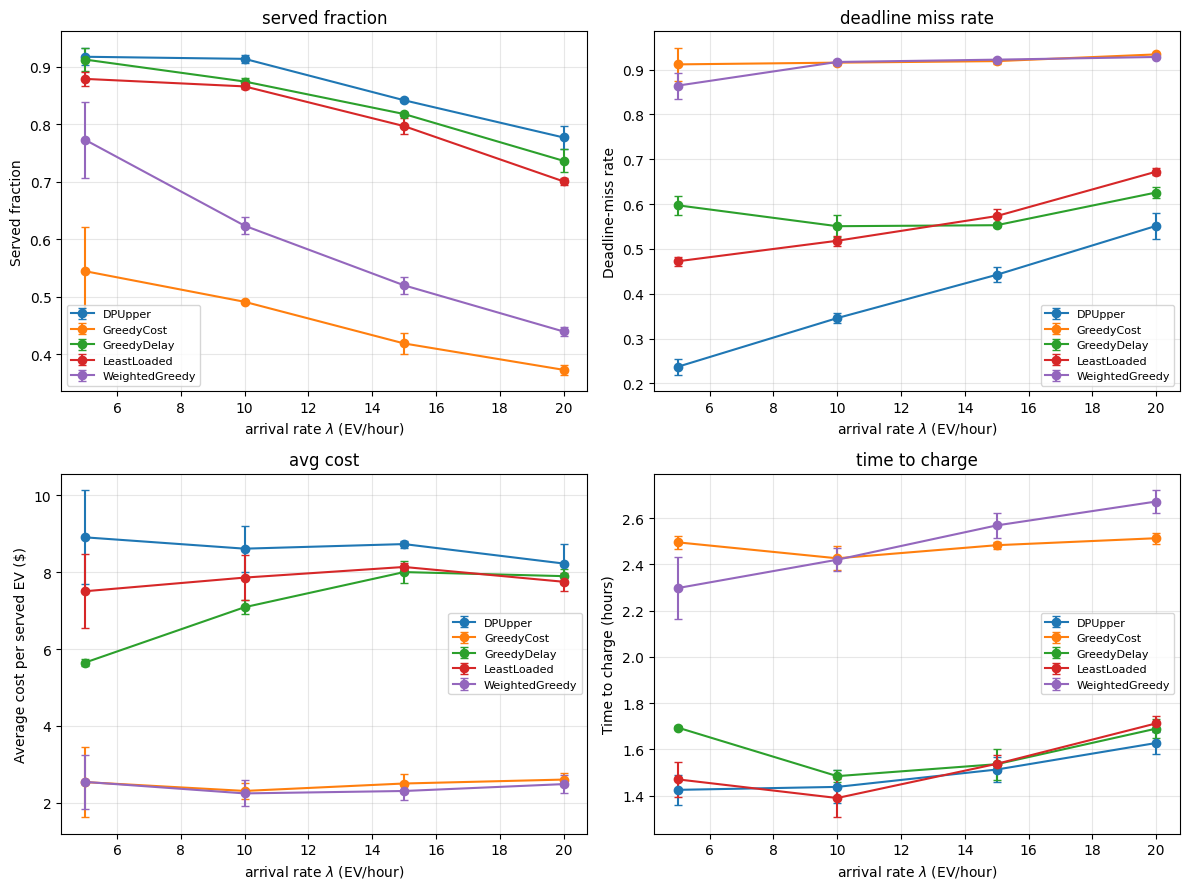

In [29]:
def plot_results(df: pd.DataFrame, save_prefix: Optional[str] = None) -> None:
    panels = [
        ("served_fraction",     "Served fraction"),
        ("deadline_miss_rate",  "Deadline-miss rate"),
        ("avg_cost",            "Average cost per served EV ($)"),
        ("time_to_charge",      "Time to charge (hours)"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.flatten()
    for ax, (metric, ylabel) in zip(axes, panels):
        sub = df[df["metric"] == metric]
        for policy, gp in sub.groupby("policy"):
            agg = gp.groupby("lambda")["value"].agg(["mean", "std"]).reset_index()
            std = agg["std"].fillna(0.0)
            ax.errorbar(agg["lambda"], agg["mean"], yerr=std,
                        marker="o", capsize=3, label=str(policy))
        ax.set_xlabel("arrival rate $\\lambda$ (EV/hour)")
        ax.set_ylabel(ylabel)
        ax.set_title(metric.replace("_", " "))
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    plt.tight_layout()
    if save_prefix:
        out = f"{save_prefix}_panels.png"
        plt.savefig(out, dpi=120, bbox_inches="tight")
        print(f"Saved {out}")
    plt.show()

plot_results(results_df, save_prefix="ev_charging_shapeB")

## 14 — Chain-usage diagnostic

In [30]:
def run_one_with_tracer(policy, lam: float, seed: int, duration: float = 8.0,
                       station_layout_fn=make_default_stations):
    env = simpy.Environment()
    stations = station_layout_fn(env)
    rng = random.Random(seed)
    sim = Simulator(env, stations, policy, default_tou(), default_sampler(), rng)
    stats_df = sim.run(arrival_rate=lam, duration=duration)
    tracer_df = sim.tracer.to_dataframe()
    return stats_df, tracer_df

Saved chain_usage_by_policy.png


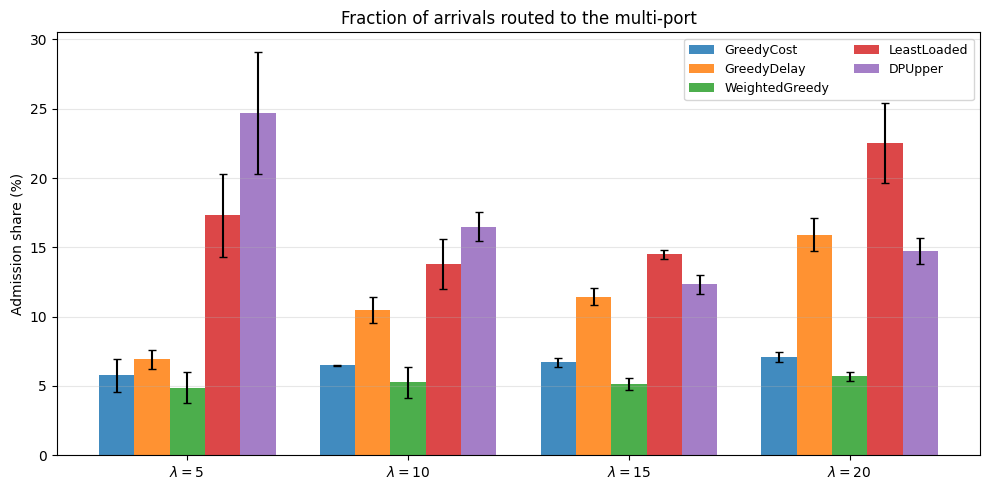

In [32]:
def plot_chain_usage(policies: dict, lambdas: list, n_seeds: int = 2,
                     duration: float = 8.0,
                     save_path: str = "chain_usage_by_policy.png"):
    rows = []
    for pname, policy in policies.items():
        for lam in lambdas:
            for seed in range(n_seeds):
                stats_df, _ = run_one_with_tracer(policy, lam, seed, duration)
                n = len(stats_df)
                chain_pct = (100.0 * stats_df["on_chain"].sum() / n) if n > 0 else 0.0
                rows.append({"policy": pname, "lambda": lam, "seed": seed,
                             "chain_pct": chain_pct})
    df = pd.DataFrame(rows)
    pivot_mean = df.pivot_table(index="lambda", columns="policy", values="chain_pct", aggfunc="mean")
    pivot_std = df.pivot_table(index="lambda", columns="policy", values="chain_pct", aggfunc="std").fillna(0.0)
    policy_order = list(policies.keys())
    pivot_mean = pivot_mean[policy_order]
    pivot_std = pivot_std[policy_order]
    n_pol = len(policy_order)
    n_lam = len(pivot_mean.index)
    width = 0.8 / n_pol
    x = np.arange(n_lam)
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, pol in enumerate(policy_order):
        offsets = x + (i - (n_pol - 1) / 2) * width
        ax.bar(offsets, pivot_mean[pol].values, width=width, label=pol,
               yerr=pivot_std[pol].values, capsize=3, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f"$\\lambda={l:g}$" for l in pivot_mean.index])
    ax.set_ylabel("Admission share (%)")
    ax.set_title("Fraction of arrivals routed to the multi-port")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=9, ncols=2)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    print(f"Saved {save_path}")
    plt.show()
    return df

_ = plot_chain_usage(POLICIES, LAMBDAS, n_seeds=2, duration=24.0,
                    save_path="chain_usage_by_policy.png")